In [1]:
using Pkg
Pkg.activate(".")
using Plots
using Unitful
using SolidStateDetectors
T = Float64;

  Activating project at `~/Phd/ChargeTrappingModel_dev/SSD_code`


In [2]:
# the geometry parameters of the model for following displaydet_rin = 1u"mm"
det_z = det_r = 10u"mm"
z_draw = det_z / 2
# CHANGE THIS WITH THE SPECIFIC VALUE FOR EACH DETECTOR
pn_r = 8.957282u"mm" # this one was calculated by searching the zero impurity point (displayed in the following section)

sim = Simulation{T}(SSD_examples[:TrueCoaxial])



Simulation{Float64, Cylindrical} - Coordinate system: Cylindrical
  Environment Material: Vacuum
  Detector: TrueCoaxial
  Electric potential: missing
  Charge density: missing
  Impurity scale: missing
  Fix Charge density: missing
  Dielectric distribution: missing
  Point types: missing
  Electric field: missing
  Weighting potentials: 
    Contact 1: missing
    Contact 2: missing


In [3]:
r_list = 0u"mm":0.01u"mm":det_r
imp_list = map(r -> let pt::CylindricalPoint{T} = CylindricalPoint(r, 0u"°", z_draw)
        SolidStateDetectors.get_impurity_density(sim.detector.semiconductor.impurity_density_model, pt) * 1e-6u"cm^-3"
    end, r_list);


In [4]:
using SolidStateDetectors: Electron, Hole
cdm = sim.detector.semiconductor.charge_drift_model
depth_list = 0u"mm":0.01u"mm":(det_r-pn_r)
mobility_list = map(depth -> let pt::CartesianPoint{T} = CartesianPoint(det_r - depth, 0, z_draw)
        (µe=SolidStateDetectors.calculate_mobility(cdm, pt, Hole) * 10000u"cm^2/(V*s)",
            µh=SolidStateDetectors.calculate_mobility(cdm, pt, Electron) * 10000u"cm^2/(V*s)")
    end, depth_list)

105-element Vector{@NamedTuple{μe::Quantity{Float64, 𝐈 𝐓^2 𝐌^-1, Unitful.FreeUnits{(cm^2, s^-1, V^-1), 𝐈 𝐓^2 𝐌^-1, nothing}}, μh::Quantity{Float64, 𝐈 𝐓^2 𝐌^-1, Unitful.FreeUnits{(cm^2, s^-1, V^-1), 𝐈 𝐓^2 𝐌^-1, nothing}}}}:
 (μe = 3516.6459043920336 cm^2 s^-1 V^-1, μh = 5219.164595302499 cm^2 s^-1 V^-1)
 (μe = 3605.6079699641205 cm^2 s^-1 V^-1, μh = 5338.537913119116 cm^2 s^-1 V^-1)
 (μe = 3701.135885605666 cm^2 s^-1 V^-1, μh = 5466.080569449311 cm^2 s^-1 V^-1)
 (μe = 3803.7148503017333 cm^2 s^-1 V^-1, μh = 5602.327426830415 cm^2 s^-1 V^-1)
 (μe = 3913.868700154684 cm^2 s^-1 V^-1, μh = 5747.847363506367 cm^2 s^-1 V^-1)
 (μe = 4032.1630397064596 cm^2 s^-1 V^-1, μh = 5903.244750719008 cm^2 s^-1 V^-1)
 (μe = 4159.208552196733 cm^2 s^-1 V^-1, μh = 6069.1607854189915 cm^2 s^-1 V^-1)
 (μe = 4295.66447523953 cm^2 s^-1 V^-1, μh = 6246.274615458353 cm^2 s^-1 V^-1)
 (μe = 4442.24222030058 cm^2 s^-1 V^-1, μh = 6435.30418097214 cm^2 s^-1 V^-1)
 (μe = 4599.709104109962 cm^2 s^-1 V^-1, μh = 6637.0066

In [5]:
# calcolo il potenziale elettrico nella griglia rozza di default
calculate_electric_potential!(sim, max_n_iterations = 10, grid = Grid(sim), verbose = false, depletion_handling = true)



In [6]:
g = sim.electric_potential.grid


Grid{Float64, 3, Cylindrical}(0.0 .. 0.01001 - length = 40, 0.0 .. 0.0 - length = 1, -1.0e-5 .. 0.01001 - length = 16)

In [7]:
# posizione dei tick lungo r,ϕ, z --> posizone dei tick e numero ti tick per ongi dimensione
ax1, ax2, ax3 = g.axes


(0.0 .. 0.01001 - length = 40, 0.0 .. 0.0 - length = 1, -1.0e-5 .. 0.01001 - length = 16)

In [8]:
bulk_tick_dis = 0.05u"mm"
dl_tick_dis   = 0.01u"mm"

0.01 mm

In [9]:
ax1.interval.left*u"m":bulk_tick_dis:pn_r

(0.0:5.0e-5:0.00895) m

In [10]:
bulk_tick_dis

0.05 mm

In [11]:
dl_tick_dis

0.01 mm

In [12]:
user_additional_ticks_ax1 = sort(vcat(ax1.interval.left*u"m":bulk_tick_dis:pn_r, pn_r:dl_tick_dis:ax1.interval.right*u"m"))
user_ax1 = typeof(ax1)(ax1.interval, SolidStateDetectors.to_internal_units.(user_additional_ticks_ax1))
user_g = typeof(g)((user_ax1, ax2, ax3))


Grid{Float64, 3, Cylindrical}(0.0 .. 0.01001 - length = 286, 0.0 .. 0.0 - length = 1, -1.0e-5 .. 0.01001 - length = 16)

In [13]:
calculate_electric_potential!(sim, refinement_limits = 0.1, grid = user_g, depletion_handling = true)
calculate_electric_field!(sim)
calculate_weighting_potential!(sim, 1, depletion_handling = true)
calculate_weighting_potential!(sim, 2, depletion_handling = true);

Simulation: TrueCoaxial
Electric Potential Calculation
Bias voltage: 500.0 V
φ symmetry: Detector is φ-symmetric -> 2D computation.
Precision: Float64
Device: CPU
Max. CPU Threads: 1
Coordinate system: Cylindrical
N Refinements: -> 1
Convergence limit: 1.0e-7  => 5.0e-5 V
Initial grid size: (286, 1, 16)

Grid size: (286, 1, 16) - using 1 threads now


┌ Info: 	In electric field calculation: Keyword `n_points_in_φ` not set.
│ 		Default is `n_points_in_φ = 36`. 2D field will be extended to 36 points in φ.
└ @ SolidStateDetectors /home/ritaferi/.julia/packages/SolidStateDetectors/4kWA0/src/Simulation/Simulation.jl:1220


Simulation: TrueCoaxial
Weighting Potential Calculation - ID: 1
φ symmetry: Detector is φ-symmetric -> 2D computation.
Precision: Float64
Device: CPU
Max. CPU Threads: 1
Coordinate system: Cylindrical
N Refinements: -> 3
Convergence limit: 1.0e-7 
Initial grid size: (12, 1, 16)

Grid size: (16, 1, 16) - using 1 threads now
Grid size: (24, 1, 16) - using 1 threads now
Grid size: (38, 1, 16) - using 1 threads now
Simulation: TrueCoaxial
Weighting Potential Calculation - ID: 2
φ symmetry: Detector is φ-symmetric -> 2D computation.
Precision: Float64
Device: CPU
Max. CPU Threads: 1
Coordinate system: Cylindrical
N Refinements: -> 3
Convergence limit: 1.0e-7 
Initial grid size: (12, 1, 16)

Grid size: (16, 1, 16) - using 1 threads now
Grid size: (24, 1, 16) - using 1 threads now
Grid size: (38, 1, 16) - using 1 threads now


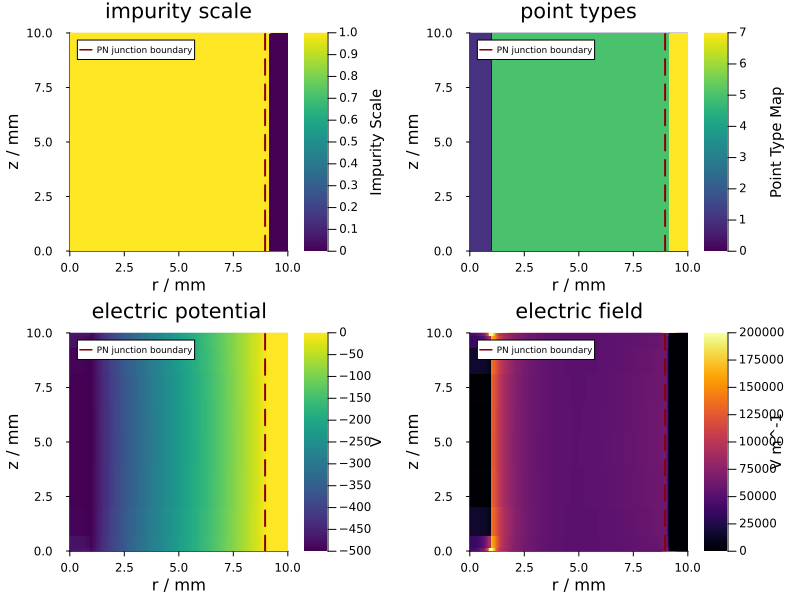

In [14]:
plot(
    begin
        imp = plot(sim.imp_scale, φ = 0, xunit = u"mm", yunit = u"mm", title = "impurity scale")
        vline!([pn_r], lw = 2, ls = :dash, color = :darkred, label = "PN junction boundary", legendfontsize = 6)
    end,
    begin
        plot(sim.point_types, φ = 0, xunit = u"mm", yunit = u"mm", title = "point types")
        vline!([pn_r], lw = 2, ls = :dash, color = :darkred, label = "PN junction boundary", legendfontsize = 6)
    end,
    begin
        plot(sim.electric_potential, xunit = u"mm", yunit = u"mm", title = "electric potential")
        vline!([pn_r], lw = 2, ls = :dash, color = :darkred, label = "PN junction boundary", legendfontsize = 6)
    end,
    begin
        plot(sim.electric_field, xunit = u"mm", yunit = u"mm", title = "electric field", clims = (0, 100*2000))
        vline!([pn_r], lw = 2, ls = :dash, color = :darkred, label = "PN junction boundary", legendfontsize = 6)
    end,
    size = (800, 600), layout = (2, 2),
)

## Pulse Shape and CCE

In [17]:
depth_list = 0.1u"mm":0.1u"mm":(det_r-pn_r)
totTime = 5u"µs"
totEnergy = 1u"keV" # --> simulating ~339 carrier pairs
N = Int(totEnergy÷2.95u"eV")  # 2.95 keV is the average energy needed to create an electron-hole pair in germanium


338

In [ ]:
# ho deifnito la lista delle profondità tra 0 e la  giunzione PN
# per ogni profondità, simulo un evento con N coppie elettrone-buca generate in quella posizione
# plotto il segnale indotto da ciascun evento.
# Infine, prendo il massimo del segnale indotto e lo divido per N per avere una stima dell'efficienza di raccolta dei portatori generati in quella profondità.


pulse_plot = plot()
# sto rimepiendo l'array CCE 
eff_list = map(depth -> begin
    r = det_r-depth
    energy_depos = fill(2.95u"eV", N)
    starting_positions = repeat([CartesianPoint(r, 0, z_draw)], N) # vario   la profondità ma tango sempre lo stesso z
    evt = Event(starting_positions, energy_depos)
    simulate!(evt, sim, Δt = 1u"ns", max_nsteps = round(Int, totTime / 1u"ns"), diffusion = true, end_drift_when_no_field = false, self_repulsion = false)
    pulse = evt.waveforms[1]
    plot!(pulse_plot, pulse, label = "Depth: $(round(typeof(depth), depth, digits = 1))", lw = 2, yunit = u"eV/V")
    maximum(pulse.signal)/N
end, depth_list)
plot!(pulse_plot, legend = :topright, xlabel = "Time / ns", ylabel = "Amplitude / e", unitformat = :nounit)
cce_plot = plot(depth_list, eff_list, xlabel = "Depth to surface / mm", ylabel = "Charge collection efficiency", lw = 2, color = :black, label = "", unitformat = :nounit)
plot(pulse_plot, cce_plot, layout = (1, 2), size = (1000, 400), margin = 5Plots.mm)

10-element Vector{Quantity{Float64, 𝐈 𝐓, Unitful.FreeUnits{(e,), 𝐈 𝐓, nothing}}}:
 4.831546028109777e-5 e
 0.003048325259584131 e
 0.01693239580360574 e
 0.05713706300705449 e
 0.0902553089541893 e
 0.1985692856087593 e
 0.38752750567653255 e
 0.686605138172729 e
 0.9994012031108844 e
 0.9999587924304458 e